<a href="https://colab.research.google.com/github/7REVOLUTiOn/UPSIS/blob/main/%D0%A3%D0%9F%D0%98%D0%A1_%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%E2%84%967_%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B1%D0%B0%D0%B7%D1%8B_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_%D0%B4%D0%BB%D1%8F_%D0%B8%D0%BD%D1%84%D0%BE%D1%80%D0%BC%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D0%BE%D0%B9_%D1%81%D0%B8%D1%81%D1%82%D0%B5%D0%BC%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Задание №7. Проектирование базы данных для информационной системы**

## **Введение**

База данных является фундаментом любой информационной системы, обеспечивая надежное хранение, эффективный доступ и целостность данных. В контексте управления проектами создания информационных систем грамотное проектирование базы данных критически важно для успеха всего проекта, поскольку ошибки на этом этапе могут привести к серьезным проблемам производительности, масштабируемости и поддержки системы в будущем.

## **Формулировка задания**

На основе ранее разработанных концептуальных основ проекта, иерархической структуры работ, спецификации требований к системе (SRS) и UML-диаграмм, спроектируйте реляционную базу данных для вашей информационной системы.

Результатом работы должна стать ER-диаграмма (Entity-Relationship Diagram), отражающая структуру данных, необходимых для функционирования вашего проекта.

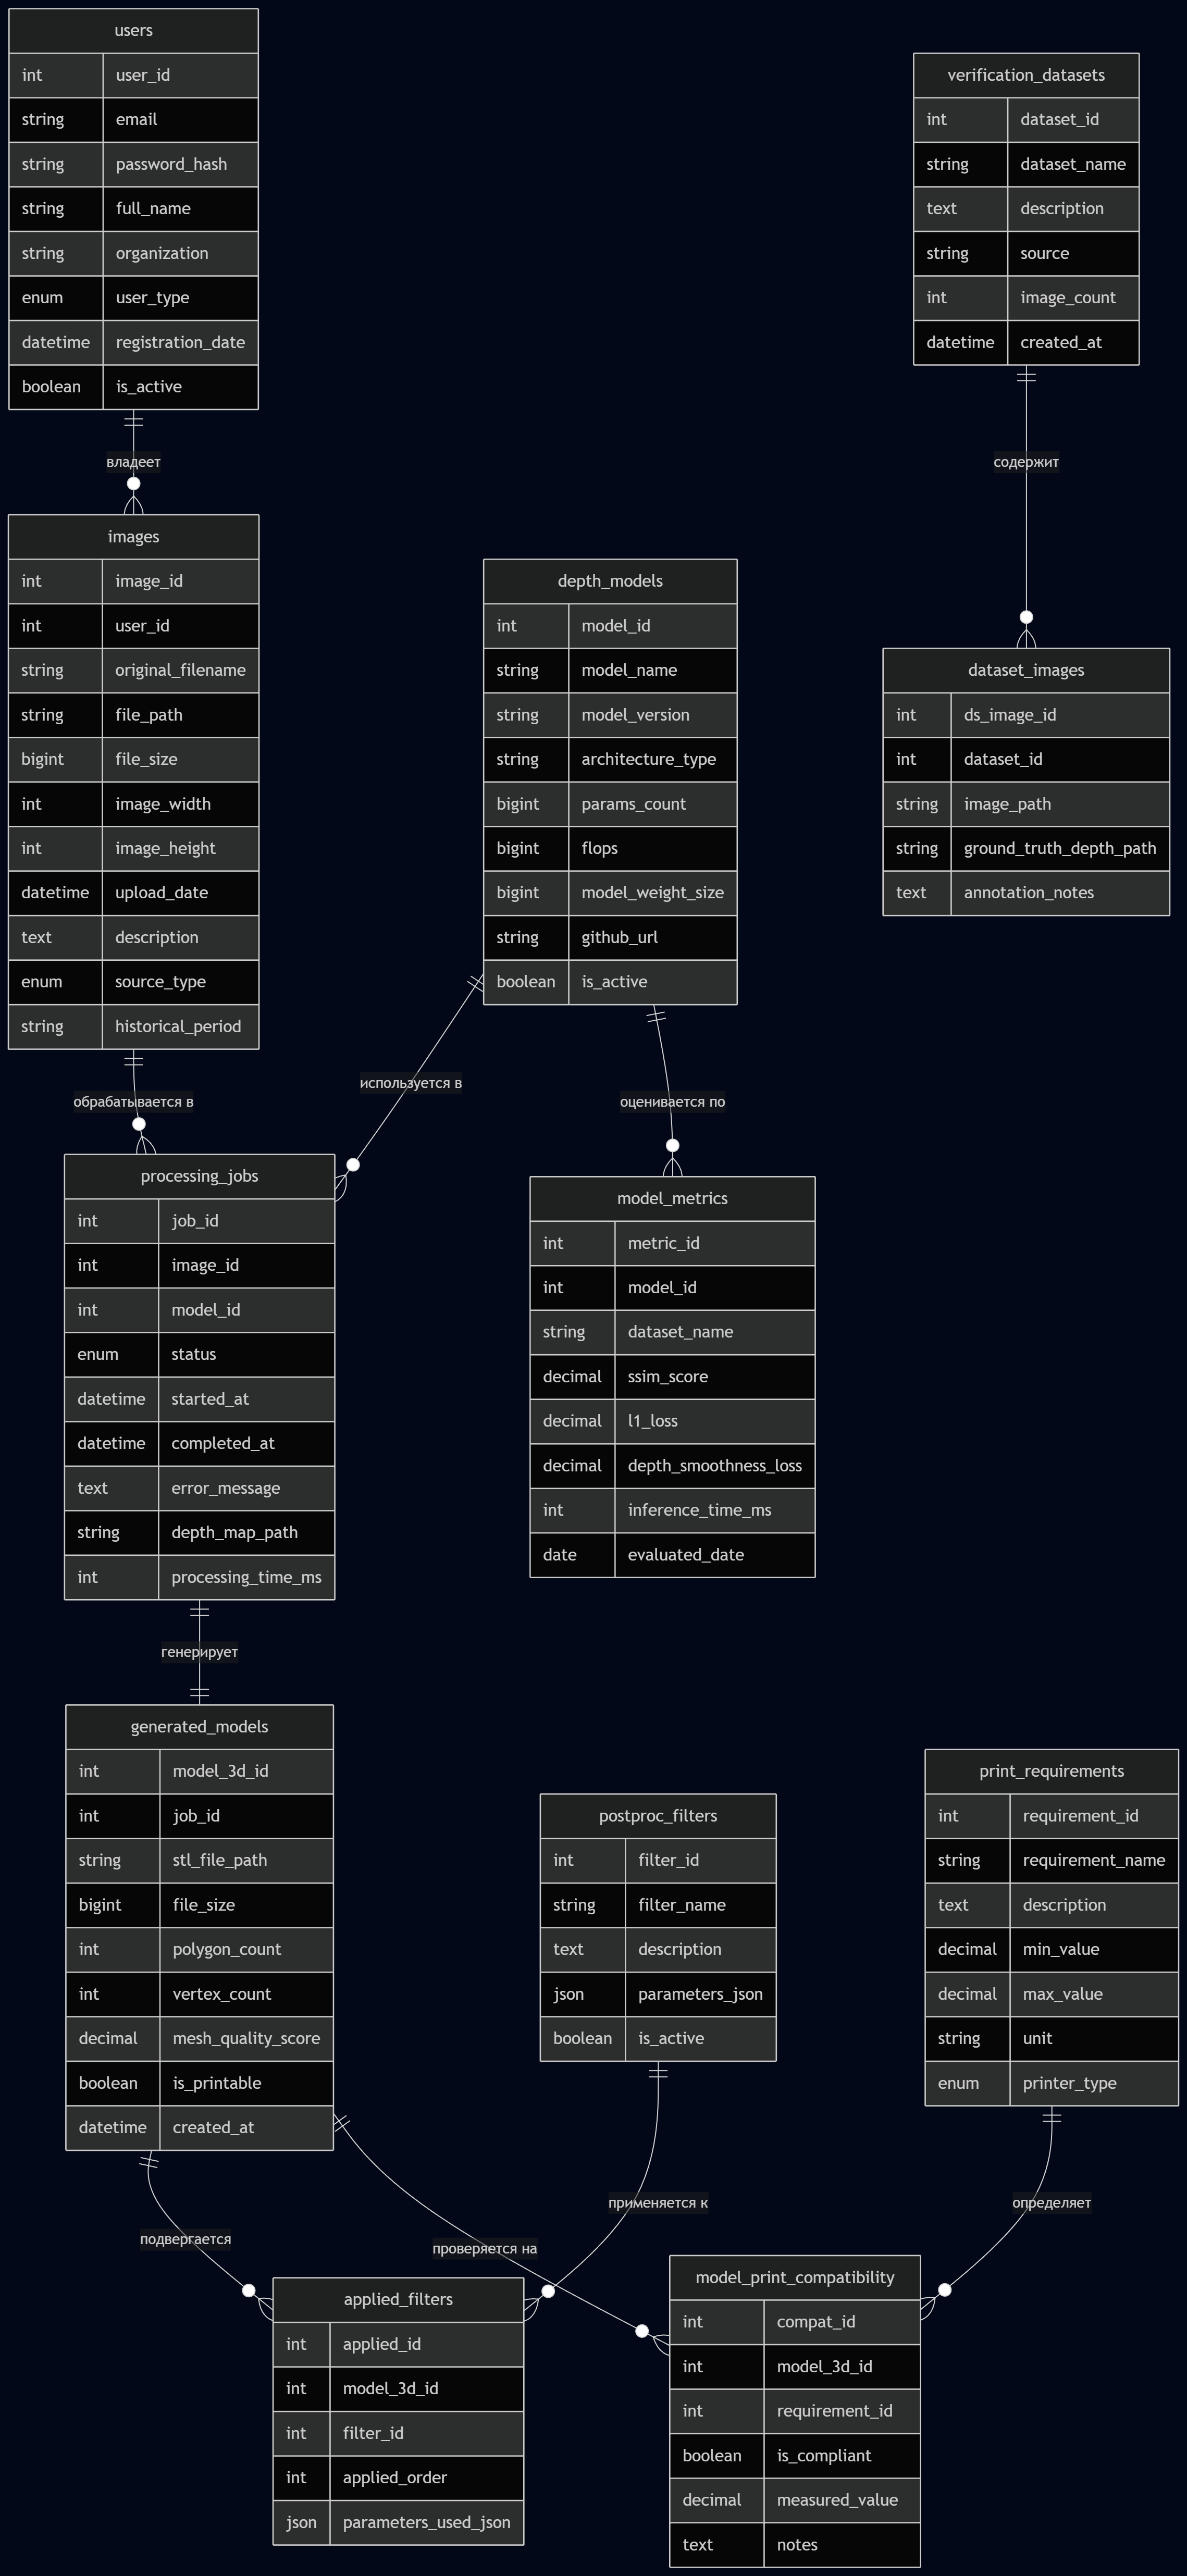

База данных состоит из 12 связанных таблиц, которые полностью (на данный момент согласования проекта) покрывают нужды системы.

Таблица users — пользователи системы

Таблица images — загруженные 2D-изображения

Таблица depth_models — модели оценки глубины

Таблица model_metrics — метрики сравнения моделей

Таблица processing_jobs — задачи обработки изображений

Таблица generated_models — сгенерированные 3D-модели (STL)

Таблица postproc_filters — методы постобработки

Таблица applied_filters — применённые фильтры

Таблица print_requirements — требования к 3D-печати

Таблица model_print_compatibility — совместимость моделей с печатью

Таблица verification_datasets — наборы данных для верификации

Таблица dataset_images — изображения из верификационных наборов



Обоснование структуры БД

Нормализация

1. Данные не дублируются: модели, фильтры и требования вынесены в отдельные справочники.
2. Нет транзитивных зависимостей: метрики моделей хранятся отдельно от их описания.
3. Связи многие-ко-многим (фильтры, требования к печати) реализованы через промежуточные таблицы — это даёт гибкость без дублей.

Масштабируемость

1. Тяжёлые файлы (STL, изображения) лежат в S3, в БД — только пути. Хранилище можно масштабировать независимо.
2. На часто используемых полях (user_id, status, upload_date) предусмотрены индексы для ускорения выборок.
3. Таблицу processing_jobs можно партиционировать по дате, чтобы архивировать старые задачи без потери производительности.

Безопасность и надёжность

1. Разделение прав через user_type + внешние ключи изолируют данные пользователей.
2. При необходимости можно добавить file_checksum для контроля целостности файлов.
3. Для аудита легко подключается таблица job_logs — по аналогии с историей статей в других проектах.

Соответствие требованиям (!)

1. Таблица model_metrics закрывает задачу сравнения моделей по SSIM/L1/FLOPs.
postproc_filters + applied_filters позволяют добавлять новые методы обработки без изменения схемы БД.
2. verification_datasets поддерживает работу с историческими фото для валидации качества.
3. print_requirements формализует критерии пригодности к 3D-печати — важно для финального результата.

In [ ]:
'''Получение истории обработок пользователя с метриками качества'''
SELECT
    i.original_filename,
    dm.model_name,
    pj.status,
    pj.processing_time_ms,
    gm.polygon_count,
    gm.is_printable,
    gm.created_at
FROM images i
JOIN processing_jobs pj ON i.image_id = pj.image_id

In [ ]:
'''Сравнительный анализ моделей по метрикам качества'''
SELECT
    dm.model_name,
    dm.model_version,
    dm.params_count,
    dm.flops,
    AVG(mm.ssim_score) as avg_ssim,
    AVG(mm.l1_loss) as avg_l1_loss,
    AVG(mm.depth_smoothness_loss) as avg_smoothness,
    AVG(mm.inference_time_ms) as avg_inference_time
FROM depth_models dm

In [ ]:
'''Проверка соответствия 3D-моделей требованиям печати'''
SELECT
    gm.model_3d_id,
    gm.polygon_count,
    gm.vertex_count,
    COUNT(CASE WHEN mpc.is_compliant = TRUE THEN 1 END) as compliant_count,
    COUNT(CASE WHEN mpc.is_compliant = FALSE THEN 1 END) as non_compliant_count,
    GROUP_CONCAT(
        CASE WHEN mpc.is_compliant = FALSE
        THEN CONCAT(pr.requirement_name, ': ', mpc.measured_value)
        END SEPARATOR '; '